## Fase #1: Análisis del Dataset
Cargar el dataset en Python usando Pandas y generar visualizaciones exploratorias con Matplotlib y Seaborn, como:

- Histogramas de las variables numéricas.
- Boxplots para detectar outliers.
- Correlación entre variables mediante heatmaps.
Y las que considere necesarias para entender el dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/avocado.csv')
print("--- Datos Cargados AAAAAAAAAAAAAA ---")
print("Primeras filas del DataFrame:")
df.head()


--- Datos Cargados AAAAAAAAAAAAAA ---
Primeras filas del DataFrame:


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [2]:
print("\nInformación del DataFrame:")
df.info()
print("\nEstadísticas descriptivas:")
df.describe()



Información del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  str    
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  str    
 12  year          18249 non-null  int64  
 13  region        18249 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 1.9 MB

Estadísticas descriptivas:


,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [3]:
print("\n Datos nulos por columna:")
df.isnull().sum()



 Datos nulos por columna:


Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

### Histograma de variables Numéricas

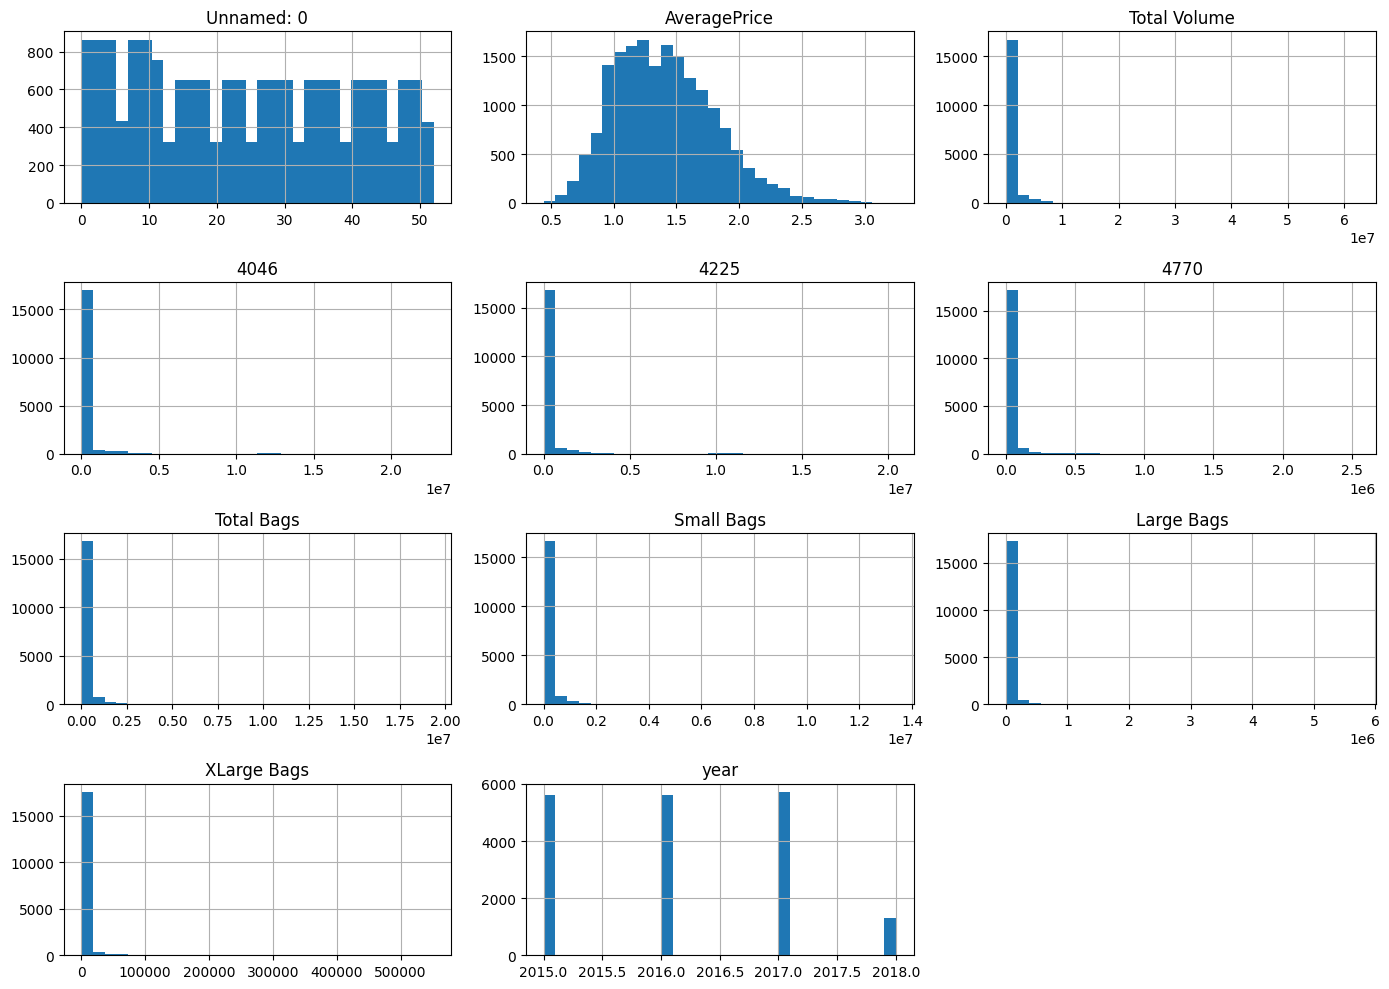

In [4]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()

- El análisis de los histogramas revela que la variable objetivo AveragePrice presenta una distribución asimétrica positiva con posible bimodalidad, que se puede relacionar a la diferencia de precios entre aguacate convencional y orgánico. 
---
- Las variables de volumen (Total Volume, PLUs 4046/4225/4770 y tipos de bolsa) exhiben distribuciones de cola pesada extremas, consecuencia de la heterogeneidad entre mercados locales y regiones agregadas. 
---
- La variable year confirma cobertura desbalanceada, con 2018 representando solo una fracción del año. 
---
- La columna Unnamed: 0 es un índice sin valor predictivo y será eliminada en la fase de limpieza.

### BoxPlots


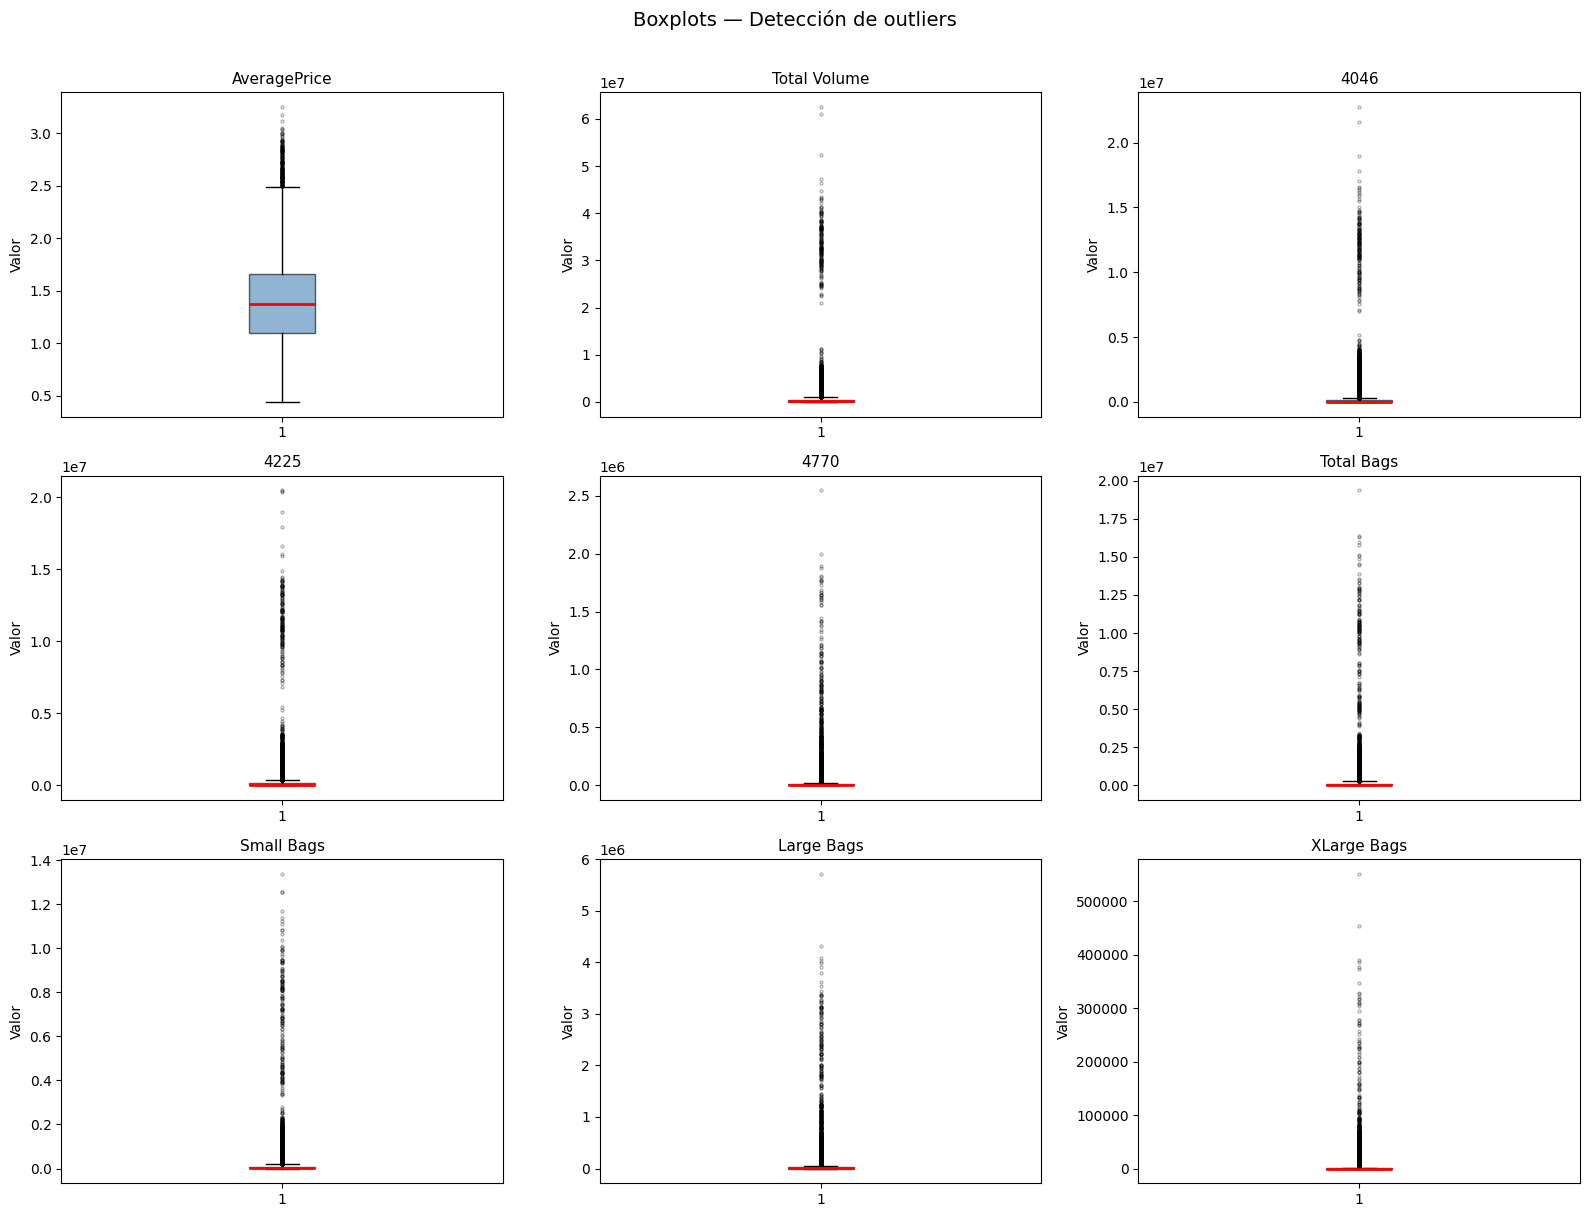

In [5]:

cols_numericas = ['AveragePrice', 'Total Volume', '4046', '4225', '4770',
                  'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots — Detección de outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### HeatMap

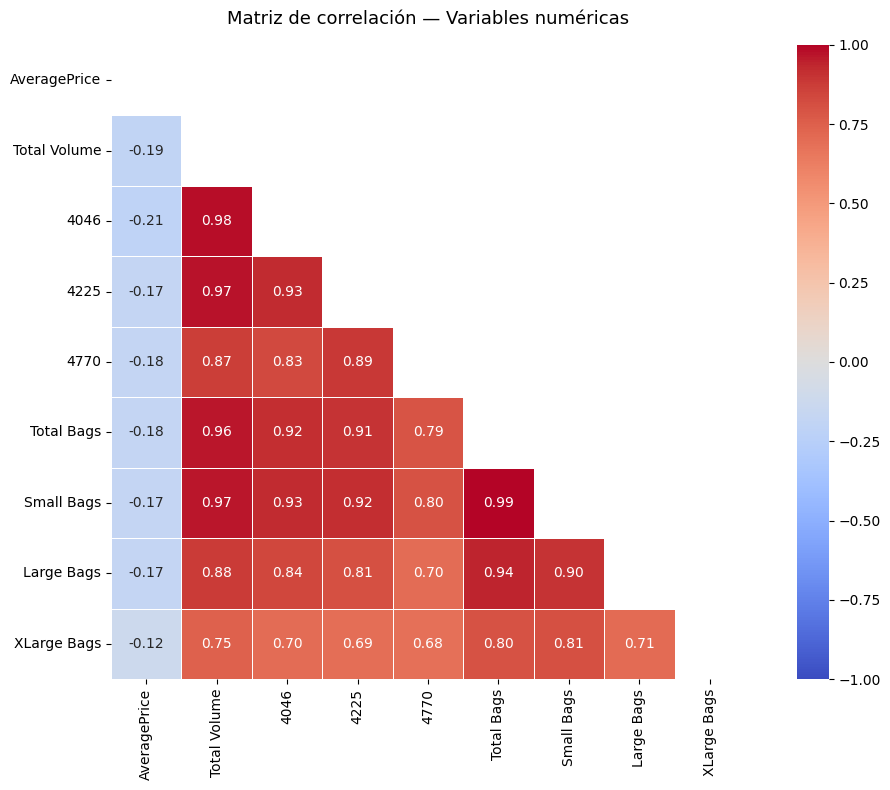

In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

corr_matrix = df[cols_numericas].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matriz de correlación — Variables numéricas', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Precios Por tipo de aguacate (Convencional y Orgánico)

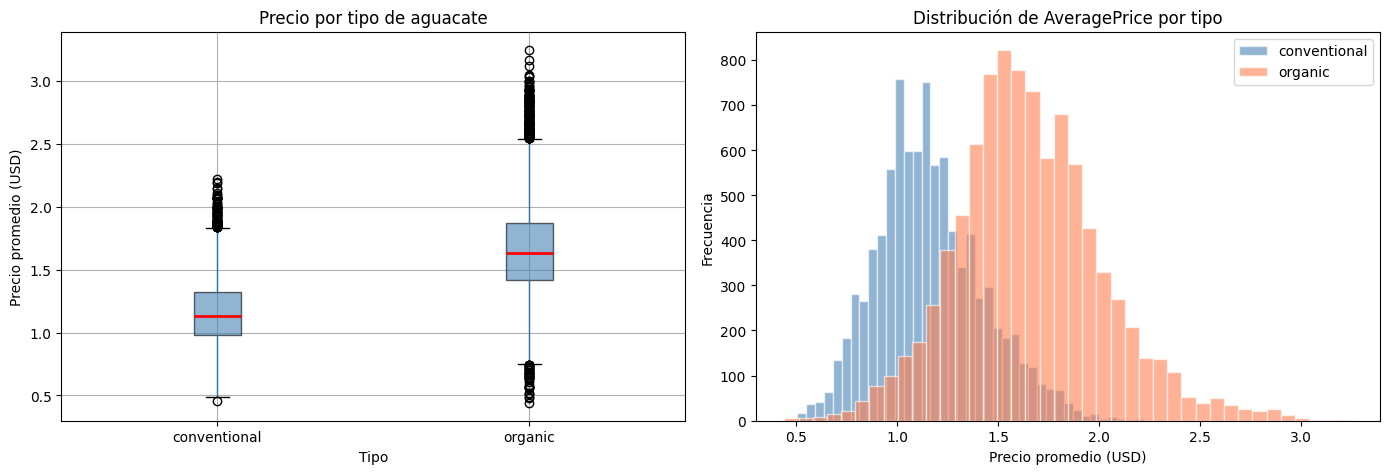

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot precio por tipo
df.boxplot(column='AveragePrice', by='type', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de precio por tipo')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Precio promedio (USD)')
plt.sca(axes[0])
plt.title('Precio por tipo de aguacate')

# Histograma superpuesto por tipo
for tipo, color in zip(['conventional', 'organic'], ['steelblue', 'coral']):
    subset = df[df['type'] == tipo]['AveragePrice']
    axes[1].hist(subset, bins=40, alpha=0.6, label=tipo, color=color, edgecolor='white')

axes[1].set_title('Distribución de AveragePrice por tipo')
axes[1].set_xlabel('Precio promedio (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.savefig('precio_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

- El boxplot izquierdo confirma lo que se intuía en el histograma que el tipo conventional tiene mediana promediando a $1.10 o $1.15 con caja entre $0.99–$1.30, mientras organic tiene mediana redondeada $1.60 con caja entre $1.45–$1.85. La diferencia es de aproximadamente $0.45 en la mediana, es decir, un 39% más caro el orgánico. Ambos tienen outliers superiores, pero el orgánico llega hasta $3.25.

---
- El histograma superpuesto de la derecha es la confirmación visual perfecta de la bimodalidad que se veía en el histograma general, son dos distribuciones distintas mezcladas. El convencional tiene distribución aproximadamente normal centrada en $1.00–$1.10, y el orgánico una distribución más ancha centrada en $1.50–$1.70. Prácticamente no se solapan entre $1.30 y $1.40, que es la zona de separación natural entre los dos tipos.
